<a href="https://colab.research.google.com/github/MaeSantos/CCADMACL_EXERCISES_COM231/blob/main/Exercise4b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 4B

In this exercise, you will learn how to use PCA for dimensionality reduction to visualize clusters and then run a clustering algorithm.

In [164]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [165]:
from sklearn.datasets import load_breast_cancer
df = load_breast_cancer(as_frame=True).frame

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [167]:
X = df.drop('target', axis=1)

1. Perform scaling `(10 pts)`

In [168]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

2. Perform dimensionality reduction using PCA `(10 pts)`

In [169]:
pca = PCA(n_components=3)
X_reduced = pca.fit_transform(X_scaled)

3. Get the total explained variance `(5 pts)`

In [170]:
explained_variance = pca.explained_variance_ratio_

PC1_explainedvariance = explained_variance[0]
print("Explained variance of PC1", PC1_explainedvariance)

PC2_explainedvariance = explained_variance[1]
print("Explained variance of PC2", PC2_explainedvariance)

PC3_explainedvariance = explained_variance[2]
print("Explained variance of PC3", PC3_explainedvariance)

Explained variance of PC1 0.44272025607526366
Explained variance of PC2 0.18971182044033078
Explained variance of PC3 0.09393163257431389


In [171]:
print("Total explained variance:", explained_variance.sum())

Total explained variance: 0.7263637090899083


4. Plot the explained variances of each principal component `(5 pts)`

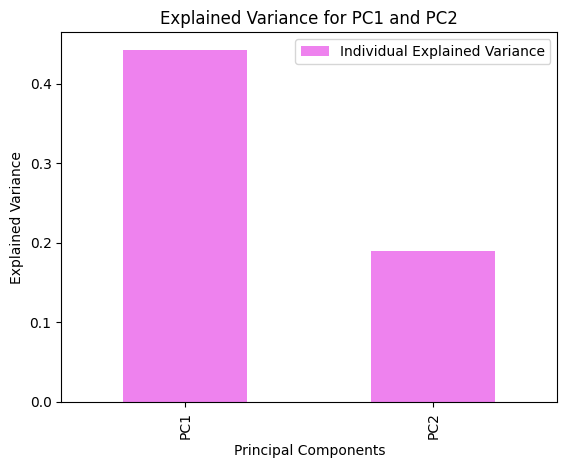

In [172]:
data = {'Principal Component': ['PC1', 'PC2'],
        'Explained Variance': [PC1_explainedvariance, PC2_explainedvariance]}
df_plot = pd.DataFrame(data)
df_plot.plot.bar(x='Principal Component', y='Explained Variance', color='violet')
plt.legend(['Individual Explained Variance'])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.title('Explained Variance for PC1 and PC2')
plt.show()

Text(0, 0.5, 'Explained Variance')

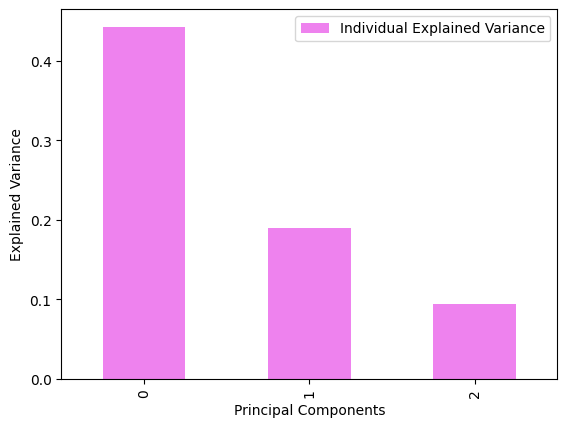

In [173]:
pd.DataFrame(explained_variance).plot.bar(color='violet')
plt.legend(['Individual Explained Variance'])
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')

5. Visualize the dataset after PCA using a scatter plot `(5 pts)`

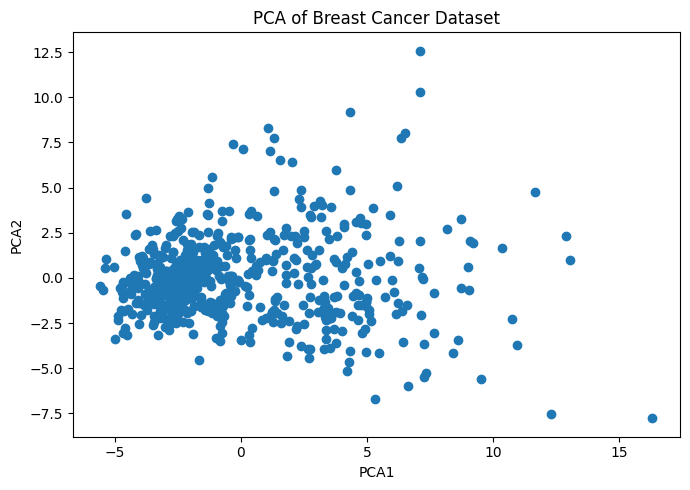

In [174]:
plt.figure(figsize=(7,5))

plt.scatter(X_reduced[:,0],X_reduced[:,1])
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('PCA of Breast Cancer Dataset')
plt.tight_layout()

In [175]:
pca_df = pd.DataFrame(data=X_reduced, columns=['PC1', 'PC2', 'PC3'])

fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    title='3D PCA Projection of Breast Cancer Dataset'
)
fig.show()

6. Perform clustering using any clustering algorithm `(10 pts)`

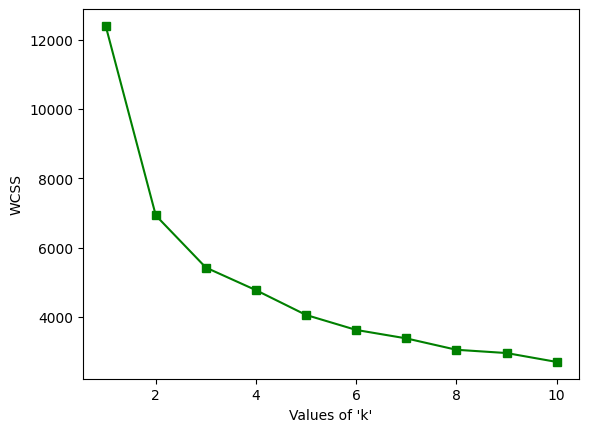

In [185]:
wcss = {}
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X_reduced)
    wcss[i] = kmeans.inertia_

plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.xlabel("Values of 'k'")
plt.ylabel('WCSS')
plt.show()

In [176]:
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,

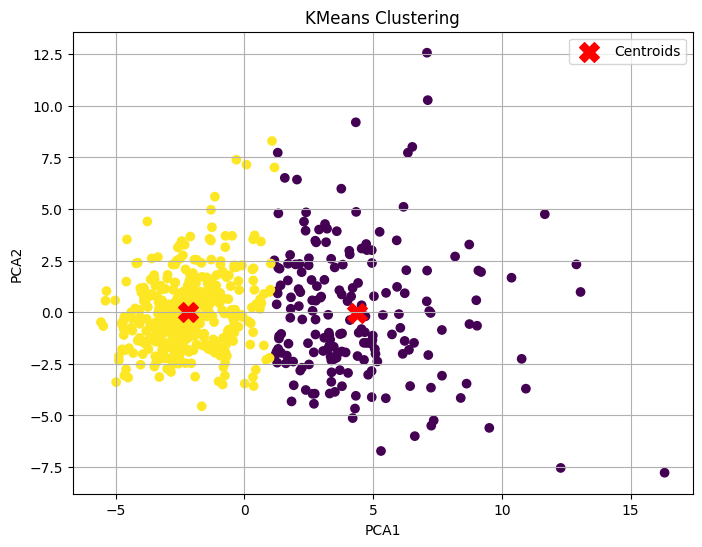

In [177]:
plt.figure(figsize=(8,6))


plt.scatter(X_reduced[:,0], X_reduced[:,1], c=clusters)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=200, c='red', label='Centroids')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('KMeans Clustering')
plt.legend()
plt.grid(True)
plt.show()

In [178]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_reduced)

pca_df = pd.DataFrame(data=X_reduced[:, :3], columns=['PC1', 'PC2', 'PC3'])
pca_df['Cluster'] = clusters

fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    title='3D PCA Projection with K-Means Clusters'
)
fig.show()

7. View the loading scores of each principal component `(5 pts)`

In [183]:
loading_matrix = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2', 'PC3'], index=X.columns)
print("Loading Scores of each Principal Component:")
print(loading_matrix)

Loading Scores of each Principal Component:
                              PC1       PC2       PC3
mean radius              0.218902 -0.233857 -0.008531
mean texture             0.103725 -0.059706  0.064550
mean perimeter           0.227537 -0.215181 -0.009314
mean area                0.220995 -0.231077  0.028700
mean smoothness          0.142590  0.186113 -0.104292
mean compactness         0.239285  0.151892 -0.074092
mean concavity           0.258400  0.060165  0.002734
mean concave points      0.260854 -0.034768 -0.025564
mean symmetry            0.138167  0.190349 -0.040240
mean fractal dimension   0.064363  0.366575 -0.022574
radius error             0.205979 -0.105552  0.268481
texture error            0.017428  0.089980  0.374634
perimeter error          0.211326 -0.089457  0.266645
area error               0.202870 -0.152293  0.216007
smoothness error         0.014531  0.204430  0.308839
compactness error        0.170393  0.232716  0.154780
concavity error          0.153590  0.1

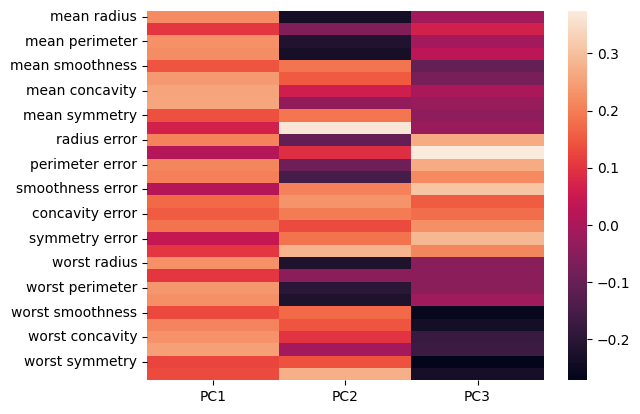

In [184]:
sns.heatmap(loading_matrix)
plt.show()